In [1]:
# Data Mining & Machine Learning Project  
## Irish Rent Price Analysis (2020–2025)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 1. Data Loading
#This section loads the dataset using pandas.
df = pd.read_csv("irish_rent_full.csv")
df.head()

,rent_euro,year,half,half_year,time_period,county,province,area,location,property_type,bedrooms,bedrooms_num,is_dublin,is_city,is_county_aggregate
0,835.90,2020,1,2020H1,1,Carlow,Leinster,Carlow,Carlow,All property types,All bedrooms,NaN,False,False,True
1,860.74,2020,1,2020H1,1,Carlow,Leinster,Carlow Town,Carlow Town,All property types,All bedrooms,NaN,False,False,False
2,910.91,2020,1,2020H1,1,Carlow,Leinster,Graiguecullen,"Graiguecullen, Carlow",All property types,All bedrooms,NaN,False,False,False
3,812.14,2020,1,2020H1,1,Carlow,Leinster,Tullow,"Tullow, Carlow",All property types,All bedrooms,NaN,False,False,False
4,666.31,2020,1,2020H1,1,Cavan,Ulster,Cavan,Cavan,All property types,All bedrooms,NaN,False,False,True


In [4]:
# 2. Data Understanding
#Exploring dataset structure, data types, and missing values.
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50208 entries, 0 to 50207
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   rent_euro            50208 non-null  float64
 1   year                 50208 non-null  int64  
 2   half                 50208 non-null  int64  
 3   half_year            50208 non-null  object 
 4   time_period          50208 non-null  int64  
 5   county               50208 non-null  object 
 6   province             50208 non-null  object 
 7   area                 50208 non-null  object 
 8   location             50208 non-null  object 
 9   property_type        50208 non-null  object 
 10  bedrooms             50208 non-null  object 
 11  bedrooms_num         37869 non-null  float64
 12  is_dublin            50208 non-null  bool   
 13  is_city              50208 non-null  bool   
 14  is_county_aggregate  50208 non-null  bool   
dtypes: bool(3), float64(2), int64(3), ob

rent_euro                  0
year                       0
half                       0
half_year                  0
time_period                0
county                     0
province                   0
area                       0
location                   0
property_type              0
bedrooms                   0
bedrooms_num           12339
is_dublin                  0
is_city                    0
is_county_aggregate        0
dtype: int64

In [5]:
# 3. Data Cleaning
# Handling missing values and preparing the dataset for analysis.
df = df.dropna()

In [6]:
df.isnull().sum()

rent_euro              0
year                   0
half                   0
half_year              0
time_period            0
county                 0
province               0
area                   0
location               0
property_type          0
bedrooms               0
bedrooms_num           0
is_dublin              0
is_city                0
is_county_aggregate    0
dtype: int64

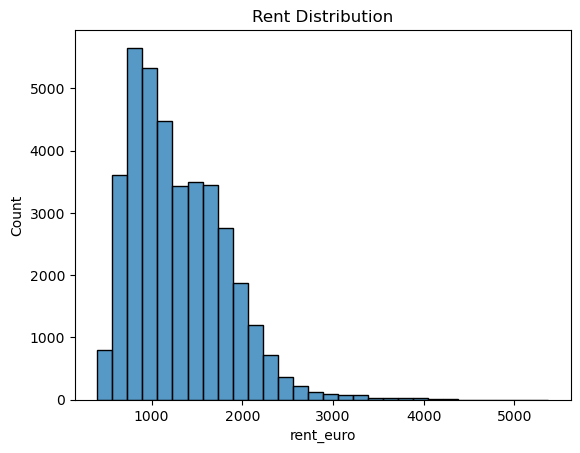

In [7]:
# 4. Exploratory Data Analysis (EDA)
# Visualizing trends and relationships in the dataset.
sns.histplot(df['rent_euro'], bins=30)
plt.title("Rent Distribution")
plt.show()

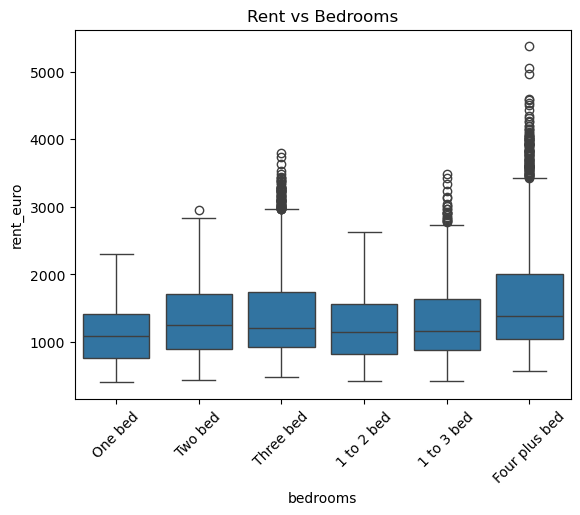

In [8]:
sns.boxplot(x=df['bedrooms'], y=df['rent_euro'])
plt.xticks(rotation=45)
plt.title("Rent vs Bedrooms")
plt.show()

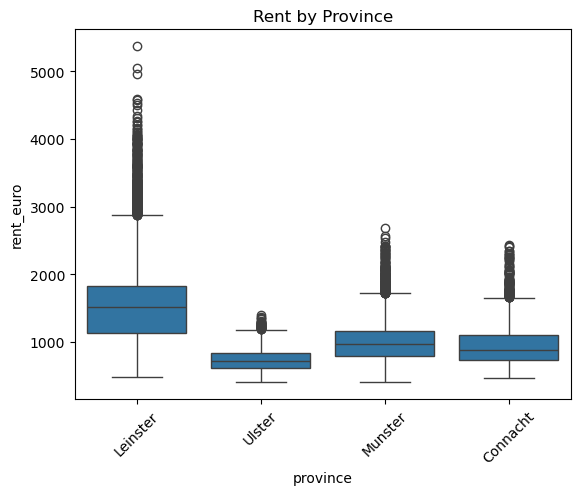

In [9]:
sns.boxplot(x=df['province'], y=df['rent_euro'])
plt.xticks(rotation=45)
plt.title("Rent by Province")
plt.show()

In [10]:
# 5. Feature Selection
# Selecting relevant features for model training.
X = df[['year', 'bedrooms_num']]

# Target
y = df['rent_euro']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# 6. Machine Learning Models
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [13]:
## 6.1 Linear Regression
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 418.59004193678857
R2 Score: 0.08241242363701862


In [14]:
# 7. Clustering (K-Means)
#Grouping rental properties into clusters based on rent and number of bedrooms.
from sklearn.cluster import KMeans

# Select features for clustering
X_cluster = df[['rent_euro', 'bedrooms_num']]

In [15]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_cluster)

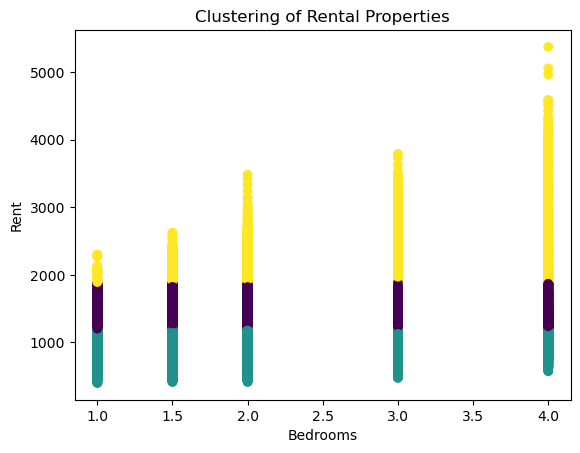

In [16]:
### Cluster Interpretation
#The clustering results show three distinct groups of rental properties:

#- Cluster 1 represents low-cost rental properties.
#- Cluster 0 represents mid-range rental properties.
#- Cluster 2 represents high-cost rental properties with higher rent values.

# This indicates that rental prices can be grouped based on affordability levels and property size.

plt.scatter(df['bedrooms_num'], df['rent_euro'], c=df['cluster'])
plt.xlabel("Bedrooms")
plt.ylabel("Rent")
plt.title("Clustering of Rental Properties")
plt.show()

In [17]:
df.groupby('cluster').mean(numeric_only=True)

,rent_euro,year,half,time_period,bedrooms_num,is_dublin,is_city,is_county_aggregate
cluster,,,,,,,,
0,1526.491568,2022.007620,1.473954,5.489193,2.073339,0.591106,0.635285,0.105209
1,883.858817,2021.776459,1.486699,5.039617,2.057135,0.033786,0.064293,0.312093
2,2241.783760,2022.349631,1.475354,6.174616,2.517561,0.932748,0.947715,0.053881


In [18]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

In [19]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

In [20]:
# Feature Importance from Random Forest

import pandas as pd

importance = rf_model.feature_importances_
features = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

print(feature_importance_df)

        Feature  Importance
0          year    0.372346
1  bedrooms_num    0.627654


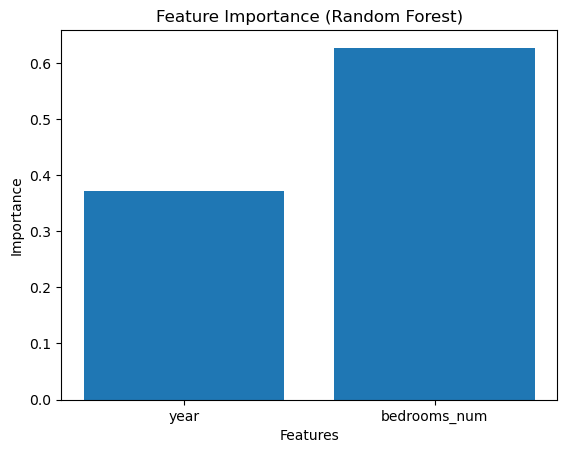

In [21]:
# Bedrooms have a higher impact on rent compared to year,
# indicating property size is a key factor in pricing.
plt.bar(features, importance)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()

In [22]:
print("\n--- Model Comparison ---")

print("Linear Regression -> MAE:", mae, "R2:", r2)
print("Decision Tree     -> MAE:", mae_dt, "R2:", r2_dt)
print("Random Forest     -> MAE:", mae_rf, "R2:", r2_rf)


--- Model Comparison ---
Linear Regression -> MAE: 418.59004193678857 R2: 0.08241242363701862
Decision Tree     -> MAE: 417.23554763219516 R2: 0.08763655379286905
Random Forest     -> MAE: 417.2335051911597 R2: 0.0876030185984118


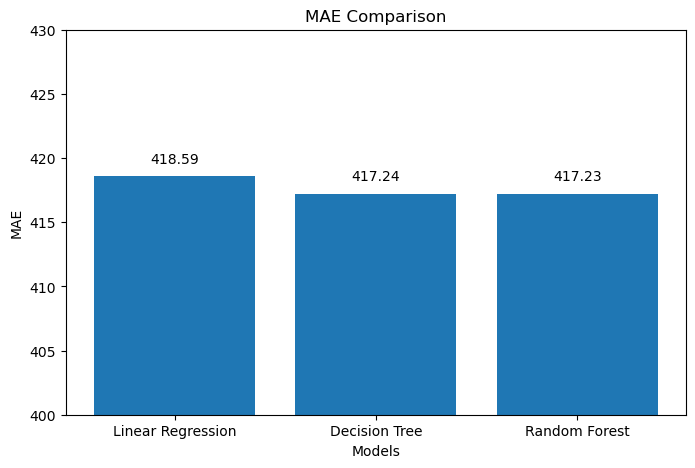

In [25]:
# This cell visualizes MAE comparison across all models

models = ['Linear Regression', 'Decision Tree', 'Random Forest']
mae_values = [mae, mae_dt, mae_rf]

plt.figure(figsize=(8,5))
plt.bar(models, mae_values)

plt.title("MAE Comparison")
plt.xlabel("Models")
plt.ylabel("MAE")

for i, v in enumerate(mae_values):
    plt.text(i, v + 1, str(round(v, 2)), ha='center')

plt.ylim(400, 430)

plt.show()

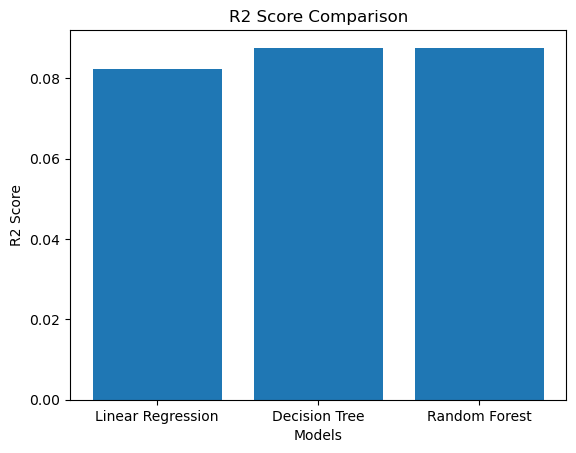

In [24]:
# This cell visualizes R2 score comparison across all models

r2_values = [r2, r2_dt, r2_rf]

plt.figure()
plt.bar(models, r2_values)
plt.title("R2 Score Comparison")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.show()